# Notebook 9 - Categorical Data Analysis

Dataset: customer_churn.csv (telecom customer churn data)
This notebook looks only at the categorical columns in the dataset and studies how the categories are spread out, whether any category is rare, and how these columns relate to the target column Churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("custumer.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


In [3]:
cat_cols = ['Gender', 'ContractType', 'InternetService', 'PaymentMethod',
            'SeniorCitizen', 'StreamingService', 'PaperlessBilling', 'Churn']
df[cat_cols].head()

,Gender,ContractType,InternetService,PaymentMethod,SeniorCitizen,StreamingService,PaperlessBilling,Churn
0,Female,One year,DSL,Bank transfer,No,No,Yes,Yes
1,Male,Two year,DSL,Credit card,Yes,Yes,No,No
2,Female,Two year,DSL,Bank transfer,No,Yes,No,No
3,Male,Month-to-month,No,Credit card,No,No,No,No
4,Male,Two year,Fiber optic,Electronic check,Yes,No,Yes,Yes


## 1. Unique Categories

### Concept
A categorical column can only take a fixed set of values. These distinct values are called the categories (or classes/levels) of that column. Before doing anything else with a categorical column, we need to know what values actually exist in it.

### Example
Gender in this data only has two values, Male and Female. ContractType has three values: Month-to-month, One year, Two year. In an HR dataset, a Department column might have categories like Sales, IT, HR, Finance.

### Why it matters for AI/ML
If we don't know the categories, we can't encode the column properly for a model, and we might miss a spelling mistake or an unexpected category hiding in the data (like "male" and "Male" being treated as different).

In [5]:
for col in cat_cols:
    print(col, "->", df[col].nunique(), "unique values")
    print(df[col].unique())
    print()

Gender -> 2 unique values
['Female' 'Male']

ContractType -> 3 unique values
['One year' 'Two year' 'Month-to-month']

InternetService -> 3 unique values
['DSL' 'No' 'Fiber optic']

PaymentMethod -> 4 unique values
['Bank transfer' 'Credit card' 'Electronic check' 'Mailed check']

SeniorCitizen -> 2 unique values
['No' 'Yes']

StreamingService -> 2 unique values
['No' 'Yes']

PaperlessBilling -> 2 unique values
['Yes' 'No']

Churn -> 2 unique values
['Yes' 'No']



**Interpretation:** Gender, SeniorCitizen, StreamingService, PaperlessBilling and Churn are all binary (2 categories only). ContractType has 3 categories, InternetService has 3, PaymentMethod has 4. None of the values look like typos or duplicates with different spelling, so the categories are clean.

**Insight:** Since most columns here are low in unique values, they can all be encoded without worrying about too many new columns being created.

## 2. Category Frequencies

### Concept
Frequency means how many times each category appears in the column. It tells us which category is common and which is rare.

### Example
If out of 100 customers, 70 have a Month-to-month contract and 30 have a Two year contract, then Month-to-month has a frequency of 70.

### Why it matters
A model trained on data where one category dominates will naturally learn that category better than the rare ones, so knowing the frequency early helps us plan for that later.

In [8]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Male      2587
Female    2433
Name: count, dtype: int64

--- ContractType ---
ContractType
Month-to-month    2236
Two year          1570
One year          1214
Name: count, dtype: int64

--- InternetService ---
InternetService
DSL            2015
Fiber optic    2006
No              999
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check    1286
Credit card         1281
Mailed check        1235
Bank transfer       1218
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
No     4118
Yes     902
Name: count, dtype: int64

--- StreamingService ---
StreamingService
Yes    2561
No     2459
Name: count, dtype: int64

--- PaperlessBilling ---
PaperlessBilling
Yes    2774
No     2246
Name: count, dtype: int64

--- Churn ---
Churn
No     3565
Yes    1455
Name: count, dtype: int64



**Interpretation:** Churn has 3565 "No" and 1455 "Yes", so the majority of customers did not churn. ContractType shows Month-to-month is the most common (2236), followed by Two year (1570) and One year (1214). PaymentMethod is fairly balanced across its four values.

**Insight:** Because Churn is not evenly split, this is something to keep in mind for later notebooks (target/class imbalance).

## 3. Category Distribution

### Concept
Distribution here means looking at frequency as a percentage of the total, instead of raw counts. This makes it easier to compare columns that don't have the same number of records, or just to talk about proportions directly.

### Example
1455 churned customers out of 5020 total is about 29%. Saying "29% of customers churned" is more useful in a report than just saying "1455 customers churned" without context.

### Why it matters
Percentages are what get reported to business stakeholders, not raw counts, so this step turns the raw numbers into something that can be communicated.

In [10]:
for col in cat_cols:
    print(f"--- {col} ---")
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print()

--- Gender ---
Gender
Male      51.53
Female    48.47
Name: proportion, dtype: float64

--- ContractType ---
ContractType
Month-to-month    44.54
Two year          31.27
One year          24.18
Name: proportion, dtype: float64

--- InternetService ---
InternetService
DSL            40.14
Fiber optic    39.96
No             19.90
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check    25.62
Credit card         25.52
Mailed check        24.60
Bank transfer       24.26
Name: proportion, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
No     82.03
Yes    17.97
Name: proportion, dtype: float64

--- StreamingService ---
StreamingService
Yes    51.02
No     48.98
Name: proportion, dtype: float64

--- PaperlessBilling ---
PaperlessBilling
Yes    55.26
No     44.74
Name: proportion, dtype: float64

--- Churn ---
Churn
No     71.02
Yes    28.98
Name: proportion, dtype: float64



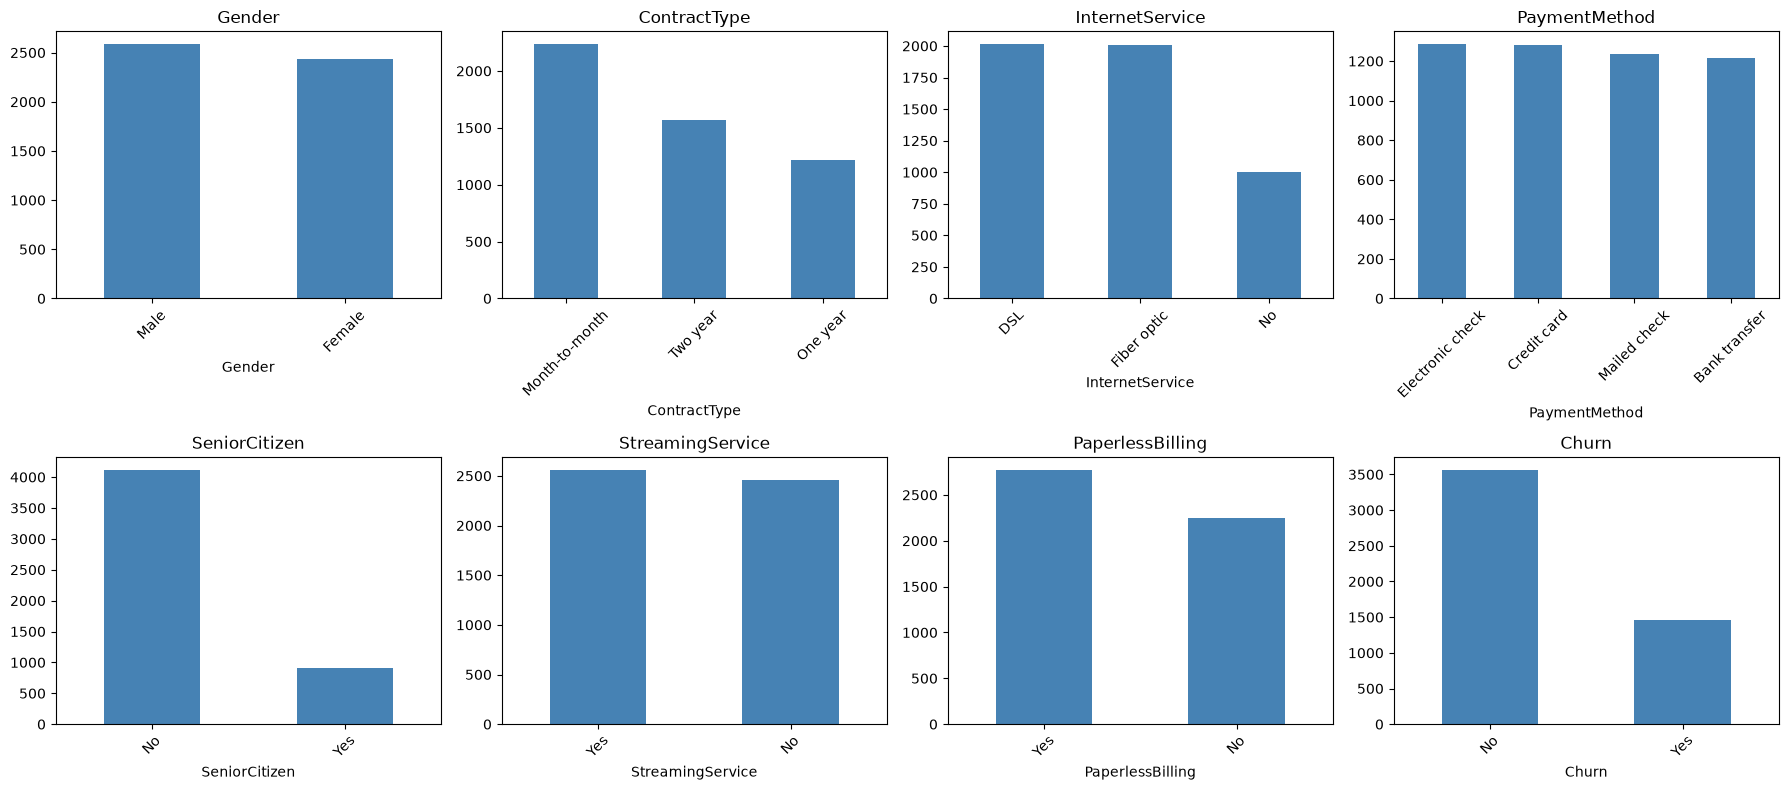

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** About 71% of customers are still with the company (Churn = No) and 29% left (Churn = Yes). ContractType is roughly 44.5% Month-to-month, 31% Two year, 24% One year. Gender is close to a 50/50 split.

**Insight:** Month-to-month customers make up a large chunk of the base, and month-to-month contracts are usually easier to leave, so this column looks worth checking against Churn later in this notebook.

## 4. Rare Categories

### Concept
A rare category is a value that appears very few times compared to the rest, for example less than 1-2% of the total records. Rare categories can cause problems: a model might not learn anything useful from a category it has barely seen, and one-hot encoding will create a column that is almost always zero.

### Example
If a Department column has 995 "Sales" and only 5 "R&D", then "R&D" is a rare category.

### Why it matters
Rare categories are usually grouped into an "Other" bucket before modeling, or handled with special encoding, so we need to know if any exist.

In [14]:
threshold = 2.0  # percent
print("Checking for rare categories (below", threshold, "% of data):\n")
for col in cat_cols:
    pct = df[col].value_counts(normalize=True) * 100
    rare = pct[pct < threshold]
    if len(rare) > 0:
        print(f"{col}:")
        print(rare)
        print()
    else:
        print(f"{col}: no rare categories\n")

Checking for rare categories (below 2.0 % of data):

Gender: no rare categories

ContractType: no rare categories

InternetService: no rare categories

PaymentMethod: no rare categories

SeniorCitizen: no rare categories

StreamingService: no rare categories

PaperlessBilling: no rare categories

Churn: no rare categories



**Interpretation:** None of the categorical columns in this dataset have a category below the 2% threshold. Every category has a reasonable number of records behind it.

**Insight:** This is good news for modeling - we won't need to merge or drop any rare category before building a model on this data.

## 5. High Cardinality vs Low Cardinality

### Concept
Cardinality means the number of unique values in a column.
- Low cardinality: few unique values (like Gender with 2, or ContractType with 3).
- High cardinality: many unique values (like a Zip Code column with hundreds of values, or a City column with thousands of values).

### Example
CustomerID has 5020 unique values for 5020 rows, so it is extremely high cardinality - actually it is an identifier, not a real category, which is why we excluded it earlier.

### Why it matters
High cardinality columns are a problem for one-hot encoding because they create hundreds of new columns. They usually need a different approach, like target encoding or grouping into fewer buckets. Low cardinality columns are easy to one-hot encode directly.

In [15]:
card = df[cat_cols].nunique().sort_values()
print(card)

print("\nCustomerID (identifier, not treated as a modeling feature):", df['CustomerID'].nunique(), "unique values")

Gender              2
PaperlessBilling    2
StreamingService    2
SeniorCitizen       2
Churn               2
ContractType        3
InternetService     3
PaymentMethod       4
dtype: int64

CustomerID (identifier, not treated as a modeling feature): 5020 unique values


**Interpretation:** All eight categorical columns we are analyzing have low cardinality, the highest being PaymentMethod with 4 values. CustomerID has 5020 unique values but it is only an identifier and will not be used as a model feature.

**Insight:** Because cardinality is low across the board, one-hot encoding will work fine here without exploding the number of columns.

## 6. Category Imbalance

### Concept
Imbalance means the categories are not roughly equal in size - one category dominates while others are much smaller. This is different from a rare category (which is extremely small); imbalance can happen even without any category being "rare".

### Example
Churn being 71% No and 29% Yes is an example of imbalance, even though 29% is not a rare/tiny amount.

### Why it matters
If we later build a classifier to predict Churn, a model can get 71% accuracy just by always predicting "No", which sounds good but is actually useless. This is why imbalance needs to be flagged early.

In [17]:
imbalance_summary = pd.DataFrame({
    col: df[col].value_counts(normalize=True).round(3) * 100
    for col in cat_cols
}).T

imbalance_summary

,Bank transfer,Credit card,DSL,Electronic check,Female,Fiber optic,Mailed check,Male,Month-to-month,No,One year,Two year,Yes
Gender,NaN,NaN,NaN,NaN,48.5,NaN,NaN,51.5,NaN,NaN,NaN,NaN,NaN
ContractType,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.5,NaN,24.2,31.3,NaN
InternetService,NaN,NaN,40.1,NaN,NaN,40.0,NaN,NaN,NaN,19.9,NaN,NaN,NaN
PaymentMethod,24.3,25.5,NaN,25.6,NaN,NaN,24.6,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.0,NaN,NaN,18.0
StreamingService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.0,NaN,NaN,51.0
PaperlessBilling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.7,NaN,NaN,55.3
Churn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,NaN,NaN,29.0


C:\Users\HP\AppData\Local\Temp\ipykernel_18604\476066226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


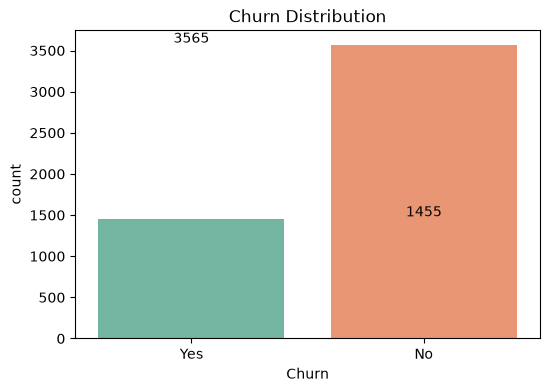

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
for i, v in enumerate(df['Churn'].value_counts()):
    plt.text(i, v + 30, str(v), ha='center')
plt.show()

**Interpretation:** Churn is the most imbalanced column here (71/29 split). ContractType is somewhat imbalanced too (Month-to-month leading at 44.5%). Gender, StreamingService and PaperlessBilling are close to balanced.

**Insight:** The Churn imbalance needs to be handled at modeling time (for example with class weights or resampling), and this should be written down as a recommendation in the final EDA report.

## 7. Categorical Columns vs Target (Churn)

### Concept
Since Churn is our target column, it is useful to check how each categorical feature relates to it. Cross-tabulation (a table comparing two categorical columns) is a simple way to do this before the full bivariate/multivariate notebooks.

### Example
Comparing ContractType against Churn tells us if, say, Month-to-month customers churn more than Two year customers.

### Why it matters
This gives an early signal about which categorical columns might actually be useful predictors for the model, before we go deeper in later notebooks.

In [20]:
for col in ['ContractType', 'InternetService', 'PaymentMethod', 'SeniorCitizen']:
    print(f"--- {col} vs Churn ---")
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(ct.round(2))
    print()

--- ContractType vs Churn ---
Churn              No    Yes
ContractType                
Month-to-month  71.20  28.80
One year        69.03  30.97
Two year        72.29  27.71

--- InternetService vs Churn ---
Churn               No    Yes
InternetService              
DSL              70.47  29.53
Fiber optic      72.23  27.77
No               69.67  30.33

--- PaymentMethod vs Churn ---
Churn                No    Yes
PaymentMethod                 
Bank transfer     70.77  29.23
Credit card       71.82  28.18
Electronic check  70.76  29.24
Mailed check      70.69  29.31

--- SeniorCitizen vs Churn ---
Churn             No    Yes
SeniorCitizen              
No             71.30  28.70
Yes            69.73  30.27



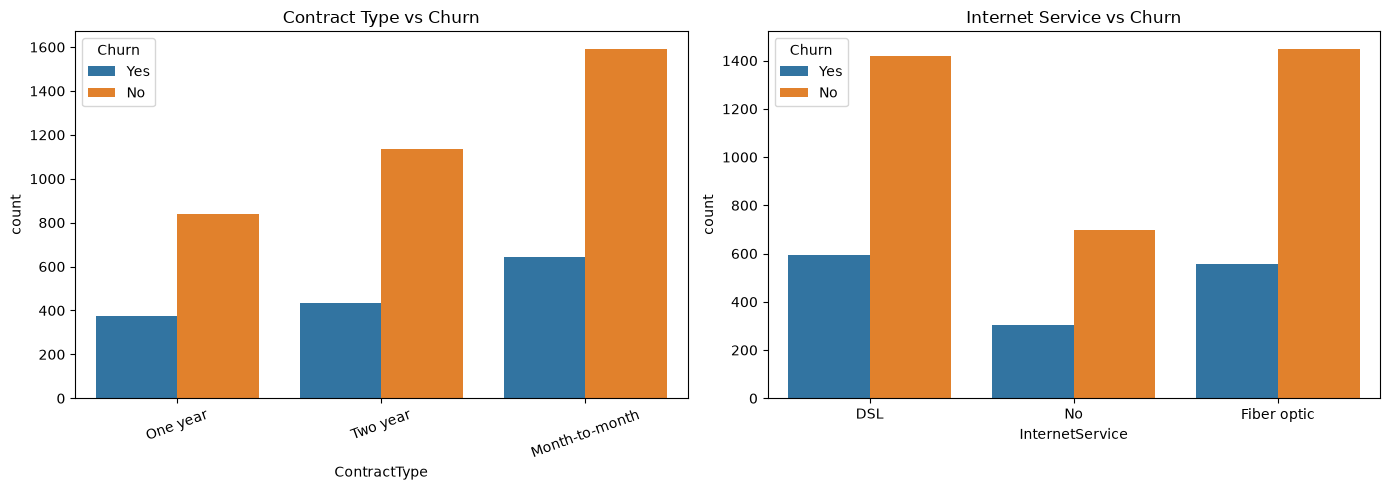

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='ContractType', hue='Churn', ax=axes[0])
axes[0].set_title('Contract Type vs Churn')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title('Internet Service vs Churn')
plt.tight_layout()
plt.show()

**Interpretation:** Month-to-month customers churn at a noticeably higher rate than One year or Two year customers, which matches the general expectation that shorter/no-commitment contracts are easier to leave. Fiber optic customers also show a higher churn rate compared to DSL or no internet service.

**Insight:** ContractType and InternetService look like they will be useful predictors for churn. This is worth carrying forward into the Bivariate and Business Insights notebooks.

### AI/ML Relevance
Categorical columns like these will need to be encoded (one-hot or ordinal, depending on the column) before they can be fed into a model. Knowing which categories are common, which are rare, and how each column relates to the target helps decide the right encoding strategy and flags Churn's class imbalance as something to handle during model training.